# Intelligent Vehicle Damage Assessment Using Deep Learning

## Model Comparison: YOLO11m vs YOLOv8m vs Faster R-CNN vs RT-DETR

This notebook trains and compares four state-of-the-art object detection models on the CarDD dataset for vehicle damage detection.

### Damage Categories
1. Dent
2. Scratch
3. Crack
4. Glass Shatter
5. Lamp Broken
6. Tire Flat

---

## 1. Setup and Configuration

In [1]:
# Install required packages (uncomment if needed)
!pip install torch torchvision ultralytics pycocotools albumentations opencv-python matplotlib seaborn pandas pyyaml tqdm tabulate

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [3]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0


In [4]:
!pip install torch torchvision torchaudio #--index-url https://download.pytorch.org/whl/cu130

  Using cached torch-2.11.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (6.9 kB)
Using cached torch-2.11.0-cp314-cp314-macosx_11_0_arm64.whl (80.6 MB)
Using cached torchvision-0.26.0-cp314-cp314-macosx_12_0_arm64.whl (1.9 MB)
Using cached torchaudio-2.11.0-cp314-cp314-macosx_12_0_arm64.whl (679 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]


In [5]:
import os
import sys
import json
import yaml
import time
import shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
# from tqdm.notebook import tqdm
from tqdm.auto import tqdm
from tabulate import tabulate

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from ultralytics import YOLO, RTDETR

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

/opt/miniconda3/envs/cnn_auto_inspec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0
Torchvision version: 0.26.0


### 1.1 Device Configuration (CUDA / MPS / CPU)

In [6]:
def get_device():
    """
    Automatically detect and return the best available device.
    Priority: CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        device_name = torch.cuda.get_device_name(0)
        device_count = torch.cuda.device_count()
        memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✓ Using CUDA: {device_name}")
        print(f"  - Available GPUs: {device_count}")
        print(f"  - GPU Memory: {memory:.2f} GB")
        return device, "cuda"
    
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✓ Using MPS (Apple Silicon GPU)")
        # Check if MPS is actually built
        if torch.backends.mps.is_built():
            print("  - MPS backend is properly built")
        return device, "mps"
    
    else:
        device = torch.device("cpu")
        print("✓ Using CPU")
        print(f"  - CPU cores: {os.cpu_count()}")
        return device, "cpu"

DEVICE, DEVICE_TYPE = get_device()
print(f"\nSelected device: {DEVICE}")

✓ Using MPS (Apple Silicon GPU)
  - MPS backend is properly built

Selected device: mps


In [7]:
# ── 1.2  Logging helpers (stdout-only, no external tracker) ──────────────────
class _PrintLogger:
    """Lightweight console logger that replaces the old ClearML no-op stubs."""
    def report_table(self, title, series, table_plot=None, **kw):
        import pandas as pd
        if table_plot is not None and isinstance(table_plot, pd.DataFrame):
            print(f'\n[{title} / {series}]')
            print(table_plot.to_string(index=False))
    def report_matplotlib_figure(self, title, series, figure=None, **kw):
        print(f'[Figure logged] {title} / {series}')
    def report_scalar(self, title, series, value=None, iteration=0, **kw):
        print(f'[Scalar] {title}/{series} = {value}')

_logger = _PrintLogger()


### 1.3 Configuration

In [8]:
# Configuration
CONFIG = {
    # Dataset paths
    'DATA_ROOT': '../data/CarDD/CarDD_COCO',
    'TRAIN_IMAGES': 'train2017',
    'VAL_IMAGES': 'val2017',
    'TEST_IMAGES': 'test2017',
    'TRAIN_ANN': 'annotations/instances_train2017.json',
    'VAL_ANN': 'annotations/instances_val2017.json',
    'TEST_ANN': 'annotations/instances_test2017.json',

    # Existing YOLO dataset location
    'YOLO_DATA_DIR': '../data/CarDD/CarDD_YOLO',

    # Model output
    'OUTPUT_DIR': '../models',
    'EXPERIMENT_NAME': f"exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}",

    # Training parameters
    'EPOCHS': 100,
    # 'BATCH_SIZE': 16 if DEVICE_TYPE == 'cuda' else 8,
    'BATCH_SIZE': 16 if DEVICE_TYPE == 'cuda' else 16,
    'IMAGE_SIZE': 640,
    'LEARNING_RATE': 0.001,
    'WEIGHT_DECAY': 0.0005,
    'NUM_WORKERS': 8 if DEVICE_TYPE != 'mps' else 0,  # MPS doesn't support multiprocessing well

    # Evaluation
    'CONF_THRESHOLD': 0.25,
    'IOU_THRESHOLD': 0.45,

    # Classes
    'NUM_CLASSES': 6,
    'CLASS_NAMES': ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat'],
}

# Adjust batch size based on device
if DEVICE_TYPE == 'mps':
    CONFIG['BATCH_SIZE'] = 8  # Reduce for MPS stability
    CONFIG['NUM_WORKERS'] = 0  # MPS has issues with multiprocessing

# Reduce workers on Windows to avoid DataLoader memory/process pressure
if os.name == 'nt':
    CONFIG['NUM_WORKERS'] = min(CONFIG['NUM_WORKERS'], 2)
    print(f"Windows detected: setting NUM_WORKERS={CONFIG['NUM_WORKERS']} for stability")

# Create output directories
os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)
os.makedirs(CONFIG['YOLO_DATA_DIR'], exist_ok=True)

print('Configuration:')
for key, value in CONFIG.items():
    print(f'  {key}: {value}')

Configuration:
  DATA_ROOT: ../data/CarDD/CarDD_COCO
  TRAIN_IMAGES: train2017
  VAL_IMAGES: val2017
  TEST_IMAGES: test2017
  TRAIN_ANN: annotations/instances_train2017.json
  VAL_ANN: annotations/instances_val2017.json
  TEST_ANN: annotations/instances_test2017.json
  YOLO_DATA_DIR: ../data/CarDD/CarDD_YOLO
  OUTPUT_DIR: ../models
  EXPERIMENT_NAME: exp_20260426_023458
  EPOCHS: 100
  BATCH_SIZE: 8
  IMAGE_SIZE: 640
  LEARNING_RATE: 0.001
  WEIGHT_DECAY: 0.0005
  NUM_WORKERS: 0
  CONF_THRESHOLD: 0.25
  IOU_THRESHOLD: 0.45
  NUM_CLASSES: 6
  CLASS_NAMES: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


In [9]:
!pip install dotenv clearml

In [10]:
import os
import dotenv 
dotenv.load_dotenv()

from clearml import Task
Task.set_credentials(
     api_host="https://api.clear.ml",
     web_host="https://app.clear.ml",
     files_host="https://files.clear.ml",
     key=os.getenv('clear_ml_key'), # get it from https://app.clear.ml/settings/workspace-configuration
     secret=os.getenv('clear_ml_secret') # get it from https://app.clear.ml/settings/workspace-configuration
)

In [11]:

# check all available projects and datasets
from clearml import Dataset
from clearml.backend_api.session.client import APIClient

# 1. Initialize the client to get the project list
client = APIClient()
projects = client.projects.get_all()

print("--- ClearML Workspace Overview ---")

for proj in projects:
    # 2. Print the Project Name
    print(f"\n📁 Project: {proj.name}")
    
    # 3. List datasets specifically for this project
    datasets = Dataset.list_datasets(
        dataset_project=proj.name,
        only_completed=False  # Shows drafts/hidden datasets too
    )
    
    if datasets:
        for ds in datasets:
            # ds is a dictionary containing metadata
            print(f"   └── 📊 Dataset: {ds['name']} (ID: {ds['id']})")
    else:
        print("   └── (No datasets found)")

--- ClearML Workspace Overview ---

📁 Project: ClearML - Nvidia Framework Examples
   └── 📊 Dataset: Example Dataset (ID: 9751c847f6664f52a096e1264b258fad)
   └── 📊 Dataset: Example data (ID: 2a619936b4204f5ebfeefefd66bddf03)

📁 Project: ClearML - Nvidia Framework Examples/Clara
2026-04-26 02:35:06,580 - clearml - WARNING - No projects were found with name(s): ^ClearML\ \-\ Nvidia\ Framework\ Examples/Clara/.*
   └── 📊 Dataset: Example data (ID: 2a619936b4204f5ebfeefefd66bddf03)

📁 Project: ClearML - Nvidia Framework Examples/TLTv3
2026-04-26 02:35:10,245 - clearml - WARNING - No projects were found with name(s): ^ClearML\ \-\ Nvidia\ Framework\ Examples/TLTv3/.*
   └── 📊 Dataset: Example Dataset (ID: 9751c847f6664f52a096e1264b258fad)

📁 Project: ClearML examples
   └── 📊 Dataset: UrbanSounds example (ID: e-21b38d1c7d22414aa4c5f5c7bda30d71)
   └── 📊 Dataset: UrbanSounds example (ID: e-f581e44aa3ee42f68206f3ec5d4b1ebc)

📁 Project: ClearML examples/Artifacts and Models
2026-04-26 02:35:1

In [12]:
from clearml import Dataset

ds = Dataset.get(
    dataset_name="CarDD_YOLO",
    dataset_project="Vehicle Damage Assessment/Datasets"
)

local_path = ds.get_local_copy()
print("Dataset path:", local_path)

██████████████████████████████ 100% | 512.40/512.4 MB [00:33<00:00, 15.45MB/s]: 
█████████████████████████████ 100% | 512.69/512.69 MB [00:33<00:00, 15.24MB/s]: /opt/miniconda3/envs/cnn_auto_inspec/lib/python3.14/site-packages/tqdm/std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
████████████████████████████ 100% | 512.69/512.69 MB [00:33<-00:00, 15.30MB/s]: 
██████████████████████████████ 100% | 512.30/512.3 MB [00:33<00:00, 15.34MB/s]: 
█████████████████████████████ 100% | 512.20/512.2 MB [00:33<-00:00, 15.46MB/s]: 
█████████████████████████████ 100% | 412.54/412.54 MB [00:27<00:00, 15.24MB/s]: 
█████████████████████████████ 100% | 411.84/411.84 MB [00:27<00:00, 15.19MB/s]: 


Dataset path: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50


---
## 2. Dataset Exploration and Preparation

In [13]:
import os
import yaml
from collections import defaultdict
from pathlib import Path
from tabulate import tabulate
data_root = Path(local_path)
# 1. Read class names directly from the YOLO cardd.yaml file
yaml_path = data_root / "cardd.yaml"
with open(yaml_path, 'r') as f:
    yolo_config = yaml.safe_load(f)
class_names = yolo_config['names']
# 2. Function to count images and labels in YOLO format
def analyze_yolo_split(split):
    img_dir = data_root / 'images' / split
    label_dir = data_root / 'labels' / split
    
    num_imgs = 0
    num_anns = 0
    class_counts = defaultdict(int)
    
    # Count image files
    if img_dir.exists():
        num_imgs = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        
    # Count annotations by reading the text files
    if label_dir.exists():
        for txt_file in os.listdir(label_dir):
            if txt_file.endswith('.txt') and not txt_file.startswith('.'):
                with open(label_dir / txt_file, 'r') as f:
                    for line in f:
                        if line.strip():
                            num_anns += 1
                            class_id = int(line.split()[0])
                            class_name = class_names[class_id]
                            class_counts[class_name] += 1
                            
    return num_imgs, num_anns, dict(class_counts)
print("Analyzing YOLO dataset from ClearML...")
train_imgs, train_anns, train_dist = analyze_yolo_split('train')
val_imgs, val_anns, val_dist = analyze_yolo_split('val')
test_imgs, test_anns, test_dist = analyze_yolo_split('test')
# 3. Print the results exactly like the old code did!
print(f"\nDataset Statistics:")
print(f"  Train: {train_imgs} images, {train_anns} annotations")
print(f"  Val:   {val_imgs} images, {val_anns} annotations")
print(f"  Test:  {test_imgs} images, {test_anns} annotations")
print("\nClass Distribution:")
table_data = []
for cls in class_names.values():
    train_c = train_dist.get(cls, 0)
    val_c = val_dist.get(cls, 0)
    test_c = test_dist.get(cls, 0)
    total_c = train_c + val_c + test_c
    table_data.append([cls, train_c, val_c, test_c, total_c])
print(tabulate(table_data, headers=["Class", "Train", "Val", "Test", "Total"], tablefmt="grid"))

Analyzing YOLO dataset from ClearML...

Dataset Statistics:
  Train: 2816 images, 6211 annotations
  Val:   810 images, 1744 annotations
  Test:  374 images, 785 annotations

Class Distribution:
+---------------+---------+-------+--------+---------+
| Class         |   Train |   Val |   Test |   Total |
+===============+=========+=======+========+=========+
| dent          |    1806 |   501 |    236 |    2543 |
+---------------+---------+-------+--------+---------+
| scratch       |    2560 |   728 |    307 |    3595 |
+---------------+---------+-------+--------+---------+
| crack         |     651 |   177 |     70 |     898 |
+---------------+---------+-------+--------+---------+
| glass shatter |     475 |   135 |     71 |     681 |
+---------------+---------+-------+--------+---------+
| lamp broken   |     494 |   141 |     69 |     704 |
+---------------+---------+-------+--------+---------+
| tire flat     |     225 |    62 |     32 |     319 |
+---------------+---------+-------+

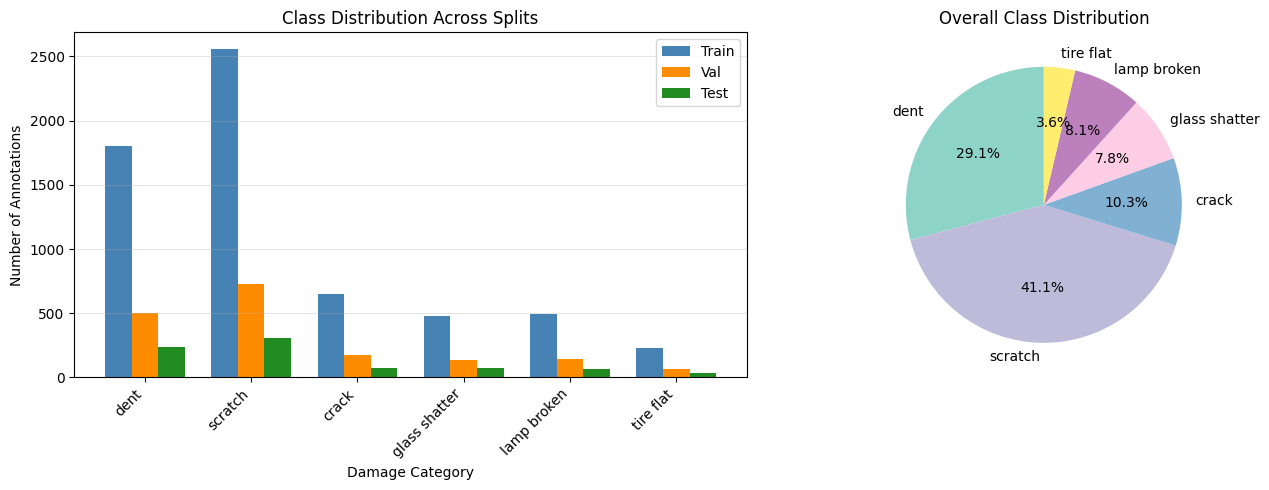

[Figure logged] Dataset / Class Distribution


In [14]:
# Convert the YOLO data from the previous block into the expected DataFrame
dist_df = pd.DataFrame(table_data, columns=["Class", "Train", "Val", "Test", "Total"])
yolo_classes = dist_df['Class'].tolist()

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(CONFIG['CLASS_NAMES']))
width = 0.25

bars1 = axes[0].bar(x - width, dist_df['Train'], width, label='Train', color='steelblue')
bars2 = axes[0].bar(x, dist_df['Val'], width, label='Val', color='darkorange')
bars3 = axes[0].bar(x + width, dist_df['Test'], width, label='Test', color='forestgreen')

axes[0].set_xlabel('Damage Category')
axes[0].set_ylabel('Number of Annotations')
axes[0].set_title('Class Distribution Across Splits')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CONFIG['CLASS_NAMES'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pie chart for total distribution
colors = plt.cm.Set3(np.linspace(0, 1, len(CONFIG['CLASS_NAMES'])))
axes[1].pie(dist_df['Total'], labels=CONFIG['CLASS_NAMES'], autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Overall Class Distribution')

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Log to ClearML
_logger.report_matplotlib_figure("Dataset", "Class Distribution", fig)

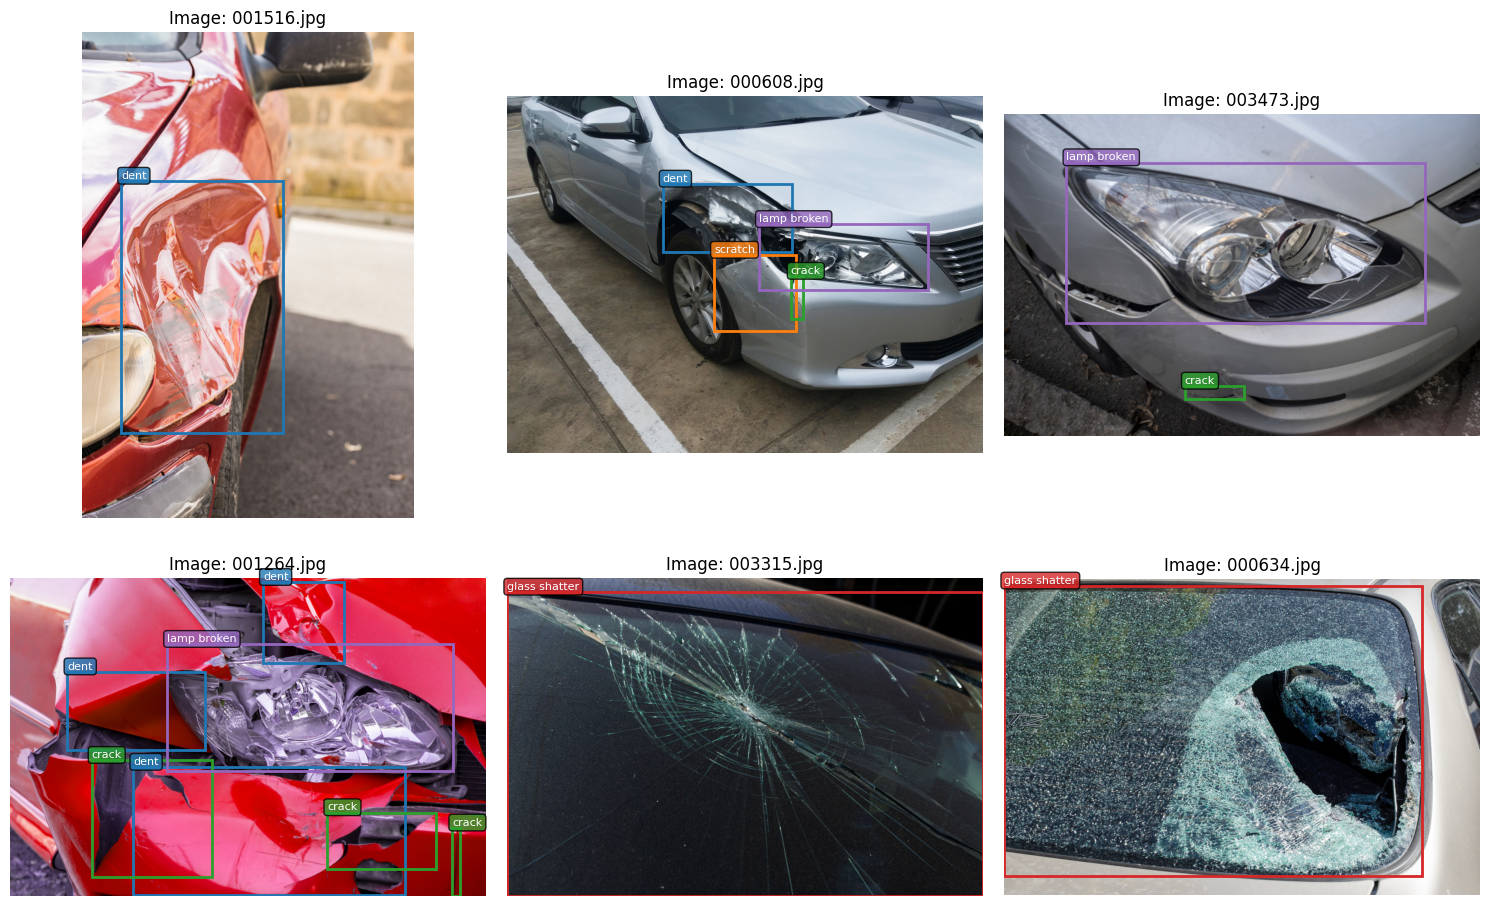

[Figure logged] Dataset / Sample Images


In [15]:
# Visualize sample images with annotations
def visualize_yolo_samples(data_root_path, split='train', num_samples=6):
    """Display sample images with bounding boxes from YOLO text annotations"""
    img_dir = data_root_path / 'images' / split
    label_dir = data_root_path / 'labels' / split
    
    # Grab the first few image files
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    img_files = img_files[:num_samples]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for idx, img_file in enumerate(img_files):
        img_path = img_dir / img_file
        img = Image.open(img_path)
        img_w, img_h = img.size
        
        axes[idx].imshow(img)
        
        # Find the matching .txt file for this image
        txt_file = os.path.splitext(img_file)[0] + '.txt'
        txt_path = label_dir / txt_file
        
        if txt_path.exists():
            with open(txt_path, 'r') as f:
                for line in f:
                    if not line.strip():
                        continue
                        
                    parts = line.strip().split()
                    cat_id = int(parts[0])
                    
                    # YOLO coordinates: [x_center, y_center, width, height] (normalized 0-1)
                    x_center, y_center, w, h = map(float, parts[1:])
                    
                    # Un-normalize coordinates back to pixel values
                    box_w = w * img_w
                    box_h = h * img_h
                    x_min = (x_center * img_w) - (box_w / 2)
                    y_min = (y_center * img_h) - (box_h / 2)
                    
                    cat_name = class_names[cat_id] # Uses the class_names dictionary we made earlier
                    color = colors[cat_id % len(colors)]
                    
                    rect = plt.Rectangle(
                        (x_min, y_min), box_w, box_h,
                        fill=False, edgecolor=color, linewidth=2
                    )
                    axes[idx].add_patch(rect)
                    axes[idx].text(
                        x_min, y_min - 5, cat_name,
                        color='white', fontsize=8,
                        bbox=dict(boxstyle='round', facecolor=color, alpha=0.8)
                    )
        
        axes[idx].set_title(f'Image: {img_file}')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['OUTPUT_DIR']}/sample_images.png", dpi=150, bbox_inches='tight')
    plt.show()
    return fig
# Call the function using our new data_root
fig = visualize_yolo_samples(data_root, split='train')
# Log to ClearML
_logger.report_matplotlib_figure("Dataset", "Sample Images", fig)

### 2.1 Prepare YOLO Format Dataset

In [16]:
# point to YOLO data directory to the ClearML data_root we defined earlier.
yolo_data_dir = os.path.abspath(data_root)
print(f"Using YOLO dataset from ClearML at: {yolo_data_dir}")
# Quick sanity check to ensure the required directories exist
expected_dirs = [
    os.path.join(yolo_data_dir, 'images', 'train'),
    os.path.join(yolo_data_dir, 'images', 'val'),
    os.path.join(yolo_data_dir, 'images', 'test'),
    os.path.join(yolo_data_dir, 'labels', 'train'),
    os.path.join(yolo_data_dir, 'labels', 'val'),
    os.path.join(yolo_data_dir, 'labels', 'test'),
]
if all(os.path.isdir(p) for p in expected_dirs):
    print("✓ All required YOLO directories found! Ready for training.")
else:
    print("⚠️ Warning: Some YOLO directories are missing from the ClearML cache!")

Using YOLO dataset from ClearML at: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50
✓ All required YOLO directories found! Ready for training.


In [17]:
yolo_data_dir_posix = Path(yolo_data_dir).resolve().as_posix()
yolo_config = {
    'path': yolo_data_dir_posix,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': CONFIG['NUM_CLASSES'],
    'names': CONFIG['CLASS_NAMES']
}
yolo_yaml_path = os.path.join(yolo_data_dir, 'dataset.yaml')
with open(yolo_yaml_path, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False)
print(f"YOLO dataset config saved to: {yolo_yaml_path}")
print("\nConfig content:")
print(yaml.dump(yolo_config, default_flow_style=False))

YOLO dataset config saved to: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50/dataset.yaml

Config content:
names:
- dent
- scratch
- crack
- glass shatter
- lamp broken
- tire flat
nc: 6
path: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50
test: images/test
train: images/train
val: images/val



---
## 3. Model Training

We will train and compare four models:
1. **YOLO11m** - Latest YOLO architecture
2. **YOLOv8m** - Popular and efficient
3. **Faster R-CNN** - Classic two-stage detector
4. **RT-DETR** - Transformer-based real-time detector

In [18]:
# Dictionary to store training results
training_results = {}
model_paths = {}

def load_ultralytics_model(model_cls, weights_name):
    """Load an Ultralytics model and recover from corrupted local weights."""
    weights_path = Path(weights_name)
    
    try:
        return model_cls(str(weights_path))
    except (OSError, RuntimeError, ValueError) as e:
        print(f"[WARN] Failed to load local weights '{weights_name}': {e}")
        if weights_path.exists():
            backup_path = weights_path.with_suffix(weights_path.suffix + '.corrupt')
            try:
                if backup_path.exists():
                    backup_path.unlink()
                weights_path.rename(backup_path)
                print(f"Moved corrupted weights to: {backup_path}")
            except Exception as move_err:
                print(f"Could not move corrupted weights file: {move_err}")
        
        print("Retrying with fresh weight download...")
        return model_cls(weights_name)

def get_safe_ultralytics_device(preferred_device_type):
    """Pick a device that can actually execute kernels."""
    if preferred_device_type == 'cuda':
        try:
            x = torch.tensor([1.0], device='cuda')
            _ = x * 2
            torch.cuda.synchronize()
            print("CUDA runtime check passed.")
            return 0
        except Exception as e:
            print(f"[WARN] CUDA runtime check failed: {e}")
            print("Falling back to CPU for training to avoid kernel launch errors.")
            return 'cpu'
    if preferred_device_type == 'mps':
        return 'mps'
    return 'cpu'

def purge_yolo_label_caches(dataset_yaml_path):
    """Remove stale cache files that can fail to load on Windows/OneDrive."""
    dataset_yaml_path = Path(dataset_yaml_path).resolve()
    if not dataset_yaml_path.exists():
        print(f"[WARN] Dataset YAML not found: {dataset_yaml_path}")
        return

    with open(dataset_yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f) or {}

    data_root = Path(data_cfg.get('path', dataset_yaml_path.parent))
    if not data_root.is_absolute():
        data_root = (dataset_yaml_path.parent / data_root).resolve()

    labels_root = data_root / 'labels'
    if not labels_root.exists():
        print(f"[WARN] Labels directory not found: {labels_root}")
        return

    cache_paths = sorted(labels_root.rglob('*.cache'))
    if not cache_paths:
        print("No YOLO cache files found.")
        return

    removed = 0
    for cache_path in cache_paths:
        try:
            if cache_path.is_dir():
                shutil.rmtree(cache_path)
            else:
                cache_path.unlink()
            removed += 1
            print(f"Removed cache: {cache_path}")
        except Exception as e:
            print(f"[WARN] Could not remove cache '{cache_path}': {e}")

    print(f"Removed {removed} cache file(s).")

def find_project_root():
    """Find repository root so path resolution is stable regardless of kernel CWD."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'models').exists() and (candidate / 'notebooks').exists():
            return candidate
    return cwd

def resolve_yolo_dataset_yaml(current_yaml_path=None):
    """Resolve a valid dataset.yaml, prioritizing CONFIG and common repository paths."""
    project_root = find_project_root()
    notebook_dir = project_root / 'notebooks'

    raw_candidates = []
    if current_yaml_path:
        raw_candidates.append(Path(current_yaml_path))

    config_yolo_dir = CONFIG.get('YOLO_DATA_DIR')
    if config_yolo_dir:
        raw_candidates.append(Path(config_yolo_dir) / 'dataset.yaml')

    raw_candidates.extend([
        Path('../data/CarDD/CarDD_YOLO/dataset.yaml'),
        Path('../data/processed/yolo_dataset/dataset.yaml'),
        Path('../models/yolo_dataset/dataset.yaml'),
    ])

    resolved_candidates = []
    for candidate in raw_candidates:
        if candidate.is_absolute():
            resolved_candidates.append(candidate.resolve())
        else:
            resolved_candidates.append((Path.cwd() / candidate).resolve())
            resolved_candidates.append((notebook_dir / candidate).resolve())

    unique_candidates = []
    seen = set()
    for candidate in resolved_candidates:
        candidate_str = str(candidate)
        if candidate_str not in seen:
            seen.add(candidate_str)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return str(candidate)

    searched = "\n".join([f"  - {c}" for c in unique_candidates[:10]])
    raise FileNotFoundError(
        "Could not find YOLO dataset.yaml. Checked:\n"
        f"{searched}\n"
        "Set CONFIG['YOLO_DATA_DIR'] to a valid YOLO dataset directory."
    )

ULTRA_DEVICE = get_safe_ultralytics_device(DEVICE_TYPE)
SAFE_TORCH_DEVICE = torch.device('cuda:0') if ULTRA_DEVICE == 0 else torch.device(ULTRA_DEVICE)
SAFE_DEVICE_TYPE = 'cuda' if ULTRA_DEVICE == 0 else ULTRA_DEVICE

if SAFE_DEVICE_TYPE == 'cpu' and CONFIG['BATCH_SIZE'] > 4:
    print(f"Adjusting batch size for CPU: {CONFIG['BATCH_SIZE']} -> 4")
    CONFIG['BATCH_SIZE'] = 4
    CONFIG['NUM_WORKERS'] = min(CONFIG['NUM_WORKERS'], 2)

# Resolve and refresh dataset path in case the kernel contains stale variables from earlier runs
yolo_yaml_path = resolve_yolo_dataset_yaml(globals().get('yolo_yaml_path'))
yolo_data_dir = str(Path(yolo_yaml_path).resolve().parent)
CONFIG['YOLO_DATA_DIR'] = yolo_data_dir
print(f"Using YOLO dataset YAML: {yolo_yaml_path}")

Using YOLO dataset YAML: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50/dataset.yaml


### 3.1 YOLO11m Training

In [ ]:
print("="*60)
print("Training YOLO11m")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize YOLO11m model
yolo11m = load_ultralytics_model(YOLO, 'yolo11m.pt')  # Load pretrained weights

# Train the model
yolo11m_results = yolo11m.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=CONFIG['BATCH_SIZE'],
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='yolo11m',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,  # Early stopping patience
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['yolo11m'] = yolo11m_results
model_paths['yolo11m'] = os.path.join(CONFIG['OUTPUT_DIR'], 'yolo11m', 'weights', 'best.pt')

print("\n✓ YOLO11m training complete!")

Training YOLO11m
Removed cache: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50/labels/train.cache
Removed cache: /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50/labels/val.cache
Removed 2 cache file(s).
Ultralytics 8.4.41 🚀 Python-3.14.3 torch-2.11.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_0a5ce277be174c47bd75b3ef202a3b50/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0,

### 3.2 YOLOv8m Training

In [ ]:
print("="*60)
print("Training YOLOv8m")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize YOLOv8m model
yolov8m = load_ultralytics_model(YOLO, 'yolov8m.pt')  # Load pretrained weights

# Train the model
yolov8m_results = yolov8m.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=CONFIG['BATCH_SIZE'],
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='yolov8m',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['yolov8m'] = yolov8m_results
model_paths['yolov8m'] = os.path.join(CONFIG['OUTPUT_DIR'], 'yolov8m', 'weights', 'best.pt')

print("\n✓ YOLOv8m training complete!")

### 3.3 YOLO26m Training

In [ ]:
print("="*60)
print("Training YOLO26m")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize YOLO26m model
yolo26m = load_ultralytics_model(YOLO, 'yolo26m.pt')  # Load pretrained weights

# Train the model
yolo26m_results = yolo26m.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=CONFIG['BATCH_SIZE'],
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='yolo26m',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['yolo26m'] = yolo26m_results
model_paths['yolo26m'] = os.path.join(CONFIG['OUTPUT_DIR'], 'yolo26m', 'weights', 'best.pt')

print("\n✓ YOLO26m training complete!")

### 3.4 Faster R-CNN Training

In [ ]:
# Dataset for Faster R-CNN
class CarDDDataset_YOLO(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.imgs = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
                
    def __getitem__(self, idx):
        img_filename = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_filename)
        img = Image.open(img_path).convert("RGB")
        img_w, img_h = img.size
        
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_filename)
        
        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    if not line.strip(): continue
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, w, h = map(float, parts[1:])
                    
                    # Convert normalized YOLO format to absolute [x_min, y_min, x_max, y_max]
                    x_min = (x_center - w/2) * img_w
                    y_min = (y_center - h/2) * img_h
                    x_max = (x_center + w/2) * img_w
                    y_max = (y_center + h/2) * img_h
                    
                    if x_max > x_min and y_max > y_min:
                        # Faster R-CNN requires class 0 to be the background, so we shift labels up by 1
                        labels.append(class_id + 1) 
                        boxes.append([x_min, y_min, x_max, y_max])
        
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((labels.shape[0],), dtype=torch.int64)
        }
        
        if self.transforms is not None:
            img = self.transforms(img)
            
        return img, target
    def __len__(self):
        return len(self.imgs)

def collate_fn(batch):
    """Custom collate function for variable-size targets"""
    return tuple(zip(*batch))

In [ ]:
def get_faster_rcnn_model(num_classes):
    """
    Get Faster R-CNN model with custom number of classes.
    Uses ResNet50 FPN V2 backbone with improved performance.
    """
    # Load pretrained model
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    
    # Get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the head with a new one (num_classes + 1 for background)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
    
    return model

# Test model creation
test_model = get_faster_rcnn_model(CONFIG['NUM_CLASSES'])
print(f"Faster R-CNN model created with {CONFIG['NUM_CLASSES'] + 1} classes (including background)")

In [ ]:
# Fix SSL certificate issue for downloading pretrained weights (macOS)
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
print("✓ SSL fix applied - you can now download pretrained models")

In [ ]:
print("="*60)
print("Training Faster R-CNN")
print("="*60)

# Create datasets
train_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = CarDDDataset_YOLO(
    os.path.join(yolo_data_dir, 'images', 'train'),
    os.path.join(yolo_data_dir, 'labels', 'train'),
    transforms=train_transform
)

val_dataset = CarDDDataset_YOLO(
    os.path.join(yolo_data_dir, 'images', 'val'),
    os.path.join(yolo_data_dir, 'labels', 'val'),
    transforms=train_transform
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=2,  # Reduced batch size for Faster R-CNN
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    collate_fn=collate_fn,
    pin_memory=True if SAFE_DEVICE_TYPE == 'cuda' else False
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=2,  # Reduced batch size
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    collate_fn=collate_fn,
    pin_memory=True if SAFE_DEVICE_TYPE == 'cuda' else False
)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset: {len(val_dataset)} images")
print(f"Faster R-CNN device: {SAFE_TORCH_DEVICE}")

In [ ]:
def train_faster_rcnn(model, train_loader, val_loader, num_epochs, device, output_dir):
    """
    Train Faster R-CNN model with validation.
    """
    model = model.to(device)
    
    # Optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        params,
        lr=CONFIG['LEARNING_RATE'],
        weight_decay=CONFIG['WEIGHT_DECAY']
    )
    
    # Learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs,
        eta_min=CONFIG['LEARNING_RATE'] * 0.01
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'learning_rate': []
    }
    
    best_loss = float('inf')
    patience_counter = 0
    patience = 20
    
    os.makedirs(output_dir, exist_ok=True)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for images, targets in pbar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            # Backward pass
            optimizer.zero_grad()
            losses.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(params, max_norm=10.0)
            
            optimizer.step()
            
            train_loss += losses.item()
            pbar.set_postfix({'loss': f'{losses.item():.4f}'})
        
        train_loss /= len(train_loader)
        
        # Validation phase
        model.train()  # Keep in train mode for loss computation
        val_loss = 0.0
        
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                val_loss += losses.item()
        
        val_loss /= len(val_loader)
        
        # Update learning rate
        lr_scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['learning_rate'].append(current_lr)
        
        # Log to ClearML
        _logger.report_scalar("Faster R-CNN", "Train Loss", train_loss, epoch)
        _logger.report_scalar("Faster R-CNN", "Val Loss", val_loss, epoch)
        _logger.report_scalar("Faster R-CNN", "Learning Rate", current_lr, epoch)
        
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}')
        
        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'train_loss': train_loss,
            }, os.path.join(output_dir, 'best.pt'))
            print(f'  -> New best model saved! Val Loss: {val_loss:.4f}')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break
        
        # Save last model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_loss,
        }, os.path.join(output_dir, 'last.pt'))
    
    return model, history

In [ ]:
# Train Faster R-CNN
faster_rcnn_model = get_faster_rcnn_model(CONFIG['NUM_CLASSES'])
faster_rcnn_output_dir = os.path.join(CONFIG['OUTPUT_DIR'], 'faster_rcnn')

faster_rcnn_model, faster_rcnn_history = train_faster_rcnn(
    faster_rcnn_model,
    train_loader,
    val_loader,
    CONFIG['EPOCHS'],
    SAFE_TORCH_DEVICE,
    faster_rcnn_output_dir
)

training_results['faster_rcnn'] = faster_rcnn_history
model_paths['faster_rcnn'] = os.path.join(faster_rcnn_output_dir, 'best.pt')

print("\n✓ Faster R-CNN training complete!")

### 3.5 RT-DETR Training

In [ ]:
print("="*60)
print("Training RT-DETR")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize RT-DETR model (using Ultralytics implementation)
rtdetr = load_ultralytics_model(RTDETR, 'rtdetr-l.pt')  # Load pretrained RT-DETR-L

# Train the model
rtdetr_results = rtdetr.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=2,  # Reduced batch size for RT-DETR
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='rtdetr',
    exist_ok=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'] * 0.1,  # Lower LR for transformer
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['rtdetr'] = rtdetr_results
model_paths['rtdetr'] = os.path.join(CONFIG['OUTPUT_DIR'], 'rtdetr', 'weights', 'best.pt')

print("\n✓ RT-DETR training complete!")

---
## 4. Model Evaluation and Comparison

In [ ]:
def evaluate_yolo_model(model_path, data_yaml, device, model_name):
    """
    Evaluate a YOLO-family model and return metrics.
    """
    print(f"\nEvaluating {model_name}...")
    
    # Load model
    if 'rtdetr' in model_name.lower():
        model = RTDETR(model_path)
    else:
        model = YOLO(model_path)
    
    # Run validation
    results = model.val(
        data=data_yaml,
        device=device,
        split='test',
        conf=CONFIG['CONF_THRESHOLD'],
        iou=CONFIG['IOU_THRESHOLD'],
        verbose=False
    )
    
    # Measure inference time
    inference_times = []
    test_images_dir = os.path.join(yolo_data_dir, 'images', 'test')
    test_images = os.listdir(test_images_dir)[:50]  # Sample 50 images
    
    for img_name in test_images:
        img_path = os.path.join(test_images_dir, img_name)
        
        start_time = time.time()
        _ = model.predict(img_path, verbose=False, device=device)
        inference_times.append((time.time() - start_time) * 1000)  # Convert to ms
    
    avg_inference_time = np.mean(inference_times)
    
    metrics = {
        'model': model_name,
        'mAP50': results.box.map50,
        'mAP50-95': results.box.map,
        'precision': results.box.mp,
        'recall': results.box.mr,
        'inference_time_ms': avg_inference_time
    }
    
    # Per-class metrics
    class_metrics = {}
    for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
        if i < len(results.box.ap50):
            class_metrics[class_name] = {
                'ap50': results.box.ap50[i],
                'ap': results.box.ap[i]
            }
    
    metrics['per_class'] = class_metrics
    
    return metrics, model

In [ ]:
def evaluate_faster_rcnn(model_path, test_dataset, device):
    """
    Evaluate Faster R-CNN model using COCO evaluation metrics.
    """
    print("\nEvaluating Faster R-CNN...")
    
    # Load model
    model = get_faster_rcnn_model(CONFIG['NUM_CLASSES'])
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Test data loader
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )
    
    # Collect predictions
    all_predictions = []
    all_targets = []
    inference_times = []
    
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc='Evaluating'):
            images = [img.to(device) for img in images]
            
            start_time = time.time()
            outputs = model(images)
            inference_times.append((time.time() - start_time) * 1000)
            
            for output, target in zip(outputs, targets):
                all_predictions.append(output)
                all_targets.append(target)
    
    # Calculate metrics
    avg_inference_time = np.mean(inference_times)
    
    # Simple mAP calculation
    def calculate_ap(predictions, targets, iou_threshold=0.5):
        """Calculate Average Precision for one class"""
        all_scores = []
        all_matches = []
        
        for pred, target in zip(predictions, targets):
            pred_boxes = pred['boxes'].cpu().numpy()
            pred_scores = pred['scores'].cpu().numpy()
            pred_labels = pred['labels'].cpu().numpy()
            
            gt_boxes = target['boxes'].cpu().numpy()
            gt_labels = target['labels'].cpu().numpy()
            
            # Filter by confidence
            conf_mask = pred_scores >= CONFIG['CONF_THRESHOLD']
            pred_boxes = pred_boxes[conf_mask]
            pred_scores = pred_scores[conf_mask]
            pred_labels = pred_labels[conf_mask]
            
            matched_gt = set()
            for i, (box, score, label) in enumerate(zip(pred_boxes, pred_scores, pred_labels)):
                all_scores.append(score)
                
                # Find matching ground truth
                best_iou = 0
                best_gt_idx = -1
                
                for j, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
                    if j in matched_gt or gt_label != label:
                        continue
                    
                    # Calculate IoU
                    x1 = max(box[0], gt_box[0])
                    y1 = max(box[1], gt_box[1])
                    x2 = min(box[2], gt_box[2])
                    y2 = min(box[3], gt_box[3])
                    
                    inter = max(0, x2 - x1) * max(0, y2 - y1)
                    area1 = (box[2] - box[0]) * (box[3] - box[1])
                    area2 = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
                    union = area1 + area2 - inter
                    
                    iou = inter / union if union > 0 else 0
                    
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j
                
                if best_iou >= iou_threshold:
                    matched_gt.add(best_gt_idx)
                    all_matches.append(1)
                else:
                    all_matches.append(0)
        
        if len(all_scores) == 0:
            return 0.0
        
        # Sort by scores
        sorted_indices = np.argsort(all_scores)[::-1]
        all_matches = np.array(all_matches)[sorted_indices]
        
        # Calculate precision and recall
        tp = np.cumsum(all_matches)
        fp = np.cumsum(1 - all_matches)
        
        total_gt = sum(len(t['boxes']) for t in targets)
        
        precision = tp / (tp + fp)
        recall = tp / total_gt if total_gt > 0 else np.zeros_like(tp)
        
        # Calculate AP using 101-point interpolation
        ap = 0
        for t in np.arange(0, 1.01, 0.01):
            prec_at_recall = precision[recall >= t]
            if len(prec_at_recall) > 0:
                ap += np.max(prec_at_recall)
        ap /= 101
        
        return ap
    
    # Calculate mAP@0.5
    mAP50 = calculate_ap(all_predictions, all_targets, iou_threshold=0.5)
    
    # Calculate mAP@0.5:0.95
    aps = []
    for iou_thresh in np.arange(0.5, 1.0, 0.05):
        aps.append(calculate_ap(all_predictions, all_targets, iou_threshold=iou_thresh))
    mAP50_95 = np.mean(aps)
    
    # Calculate precision and recall
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for pred, target in zip(all_predictions, all_targets):
        pred_boxes = pred['boxes'].cpu().numpy()
        pred_scores = pred['scores'].cpu().numpy()
        gt_boxes = target['boxes'].cpu().numpy()
        
        conf_mask = pred_scores >= CONFIG['CONF_THRESHOLD']
        pred_boxes = pred_boxes[conf_mask]
        
        matched = 0
        for box in pred_boxes:
            for gt_box in gt_boxes:
                x1 = max(box[0], gt_box[0])
                y1 = max(box[1], gt_box[1])
                x2 = min(box[2], gt_box[2])
                y2 = min(box[3], gt_box[3])
                
                inter = max(0, x2 - x1) * max(0, y2 - y1)
                area1 = (box[2] - box[0]) * (box[3] - box[1])
                area2 = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
                union = area1 + area2 - inter
                
                if inter / union >= 0.5:
                    matched += 1
                    break
        
        total_tp += matched
        total_fp += len(pred_boxes) - matched
        total_fn += len(gt_boxes) - matched
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    
    metrics = {
        'model': 'Faster R-CNN',
        'mAP50': mAP50,
        'mAP50-95': mAP50_95,
        'precision': precision,
        'recall': recall,
        'inference_time_ms': avg_inference_time
    }
    
    return metrics, model

In [ ]:
# Evaluate all models
print("="*60)
print("Evaluating All Models on Test Set")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

evaluation_results = {}
loaded_models = {}

# Evaluate YOLO11m
if os.path.exists(model_paths.get('yolo11m', '')):
    metrics, model = evaluate_yolo_model(
        model_paths['yolo11m'], 
        yolo_yaml_path, 
        SAFE_DEVICE_TYPE,
        'YOLO11m'
    )
    evaluation_results['yolo11m'] = metrics
    loaded_models['yolo11m'] = model

# Evaluate YOLOv8m
if os.path.exists(model_paths.get('yolov8m', '')):
    metrics, model = evaluate_yolo_model(
        model_paths['yolov8m'], 
        yolo_yaml_path, 
        SAFE_DEVICE_TYPE,
        'YOLOv8m'
    )
    evaluation_results['yolov8m'] = metrics
    loaded_models['yolov8m'] = model

# Evaluate Faster R-CNN
if os.path.exists(model_paths.get('faster_rcnn', '')):
    test_dataset = CarDDDataset(
        test_coco,
        data_root / CONFIG['TEST_IMAGES'],
        transforms=transforms.Compose([transforms.ToTensor()])
    )
    metrics, model = evaluate_faster_rcnn(
        model_paths['faster_rcnn'],
        test_dataset,
        SAFE_TORCH_DEVICE
    )
    evaluation_results['faster_rcnn'] = metrics
    loaded_models['faster_rcnn'] = model

# Evaluate RT-DETR
if os.path.exists(model_paths.get('rtdetr', '')):
    metrics, model = evaluate_yolo_model(
        model_paths['rtdetr'], 
        yolo_yaml_path, 
        SAFE_DEVICE_TYPE,
        'RT-DETR'
    )
    evaluation_results['rtdetr'] = metrics
    loaded_models['rtdetr'] = model

print("\n✓ All model evaluations complete!")

### 4.1 Results Comparison

In [ ]:
# Create comparison table
comparison_data = []

for model_name, metrics in evaluation_results.items():
    comparison_data.append({
        'Model': metrics['model'],
        'mAP@0.5': f"{metrics['mAP50']:.4f}",
        'mAP@0.5:0.95': f"{metrics['mAP50-95']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Inference (ms)': f"{metrics['inference_time_ms']:.2f}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

# Log to ClearML
_logger.report_table("Model Comparison", "Test Set Results", table_plot=comparison_df)

# Save to CSV
comparison_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/model_comparison.csv", index=False)
print(f"\nResults saved to: {CONFIG['OUTPUT_DIR']}/model_comparison.csv")

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [m['model'] for m in comparison_data]
map50 = [float(m['mAP@0.5']) for m in comparison_data]
map50_95 = [float(m['mAP@0.5:0.95']) for m in comparison_data]
precision = [float(m['Precision']) for m in comparison_data]
recall = [float(m['Recall']) for m in comparison_data]
inference = [float(m['Inference (ms)']) for m in comparison_data]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))

# mAP comparison
x = np.arange(len(models))
width = 0.35
axes[0, 0].bar(x - width/2, map50, width, label='mAP@0.5', color='steelblue')
axes[0, 0].bar(x + width/2, map50_95, width, label='mAP@0.5:0.95', color='darkorange')
axes[0, 0].set_ylabel('mAP')
axes[0, 0].set_title('Mean Average Precision')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Precision & Recall
axes[0, 1].bar(x - width/2, precision, width, label='Precision', color='forestgreen')
axes[0, 1].bar(x + width/2, recall, width, label='Recall', color='crimson')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Precision & Recall')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=15)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Inference time
axes[1, 0].bar(models, inference, color=colors)
axes[1, 0].set_ylabel('Time (ms)')
axes[1, 0].set_title('Inference Time per Image')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(axis='y', alpha=0.3)

# Efficiency plot (mAP vs Speed)
for i, model in enumerate(models):
    axes[1, 1].scatter(inference[i], map50[i], s=200, c=[colors[i]], label=model, edgecolors='black')
axes[1, 1].set_xlabel('Inference Time (ms)')
axes[1, 1].set_ylabel('mAP@0.5')
axes[1, 1].set_title('Accuracy vs Speed Trade-off')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

_logger.report_matplotlib_figure("Comparison", "Model Metrics", fig)

### 4.2 Per-Class Performance Analysis

In [ ]:
# Per-class AP comparison (for YOLO models)
per_class_data = []

for model_name, metrics in evaluation_results.items():
    if 'per_class' in metrics:
        for class_name, class_metrics in metrics['per_class'].items():
            per_class_data.append({
                'Model': metrics['model'],
                'Class': class_name,
                'AP@0.5': class_metrics.get('ap50', 0),
                'AP@0.5:0.95': class_metrics.get('ap', 0)
            })

if per_class_data:
    per_class_df = pd.DataFrame(per_class_data)
    
    # Pivot for visualization
    pivot_df = per_class_df.pivot(index='Class', columns='Model', values='AP@0.5')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_ylabel('AP@0.5')
    ax.set_title('Per-Class Average Precision Comparison')
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{CONFIG['OUTPUT_DIR']}/per_class_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    _logger.report_matplotlib_figure("Comparison", "Per-Class AP", fig)

### 4.3 Select Best Model

In [ ]:
# Determine the best model based on mAP@0.5
best_model_name = None
best_map50 = 0

for model_name, metrics in evaluation_results.items():
    if metrics['mAP50'] > best_map50:
        best_map50 = metrics['mAP50']
        best_model_name = model_name

print("="*60)
print("BEST MODEL SELECTION")
print("="*60)
print(f"\nBest Model: {evaluation_results[best_model_name]['model']}")
print(f"   mAP@0.5: {best_map50:.4f}")
print(f"   mAP@0.5:0.95: {evaluation_results[best_model_name]['mAP50-95']:.4f}")
print(f"   Inference Time: {evaluation_results[best_model_name]['inference_time_ms']:.2f} ms")

# Copy best model to deployment location
best_model_src = model_paths[best_model_name]
best_model_dst = os.path.join(CONFIG['OUTPUT_DIR'], 'best_model.pt')

if os.path.exists(best_model_src):
    shutil.copy2(best_model_src, best_model_dst)
    print(f"\n✓ Best model saved to: {best_model_dst}")

# Log to ClearML (no-op when disabled)


---
## 5. Inference Demonstration

In [ ]:
def visualize_predictions(model, image_path, model_name, conf_threshold=0.25):
    """
    Visualize model predictions on a single image.
    """
    # Load and predict
    if isinstance(model, (YOLO, RTDETR)):
        results = model.predict(image_path, conf=conf_threshold, verbose=False, device=SAFE_DEVICE_TYPE)
        
        # Get annotated image
        annotated = results[0].plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        
        detections = results[0].boxes
        
    else:  # Faster R-CNN
        img = Image.open(image_path).convert('RGB')
        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(SAFE_TORCH_DEVICE)
        
        model.eval()
        with torch.no_grad():
            predictions = model(img_tensor)[0]
        
        # Draw predictions
        annotated = np.array(img)
        
        for i, (box, score, label) in enumerate(zip(
            predictions['boxes'].cpu().numpy(),
            predictions['scores'].cpu().numpy(),
            predictions['labels'].cpu().numpy()
        )):
            if score >= conf_threshold:
                x1, y1, x2, y2 = box.astype(int)
                class_name = CONFIG['CLASS_NAMES'][label - 1]
                
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    annotated, f'{class_name}: {score:.2f}',
                    (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2
                )
        
        detections = predictions
    
    return annotated, detections

# Visualize predictions from best model on sample test images
test_images_dir = data_root / CONFIG['TEST_IMAGES']
sample_images = list(test_images_dir.glob('*.jpg'))[:6]

if best_model_name and loaded_models.get(best_model_name):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(sample_images):
        annotated, _ = visualize_predictions(
            loaded_models[best_model_name],
            str(img_path),
            best_model_name
        )
        axes[idx].imshow(annotated)
        axes[idx].set_title(f'{img_path.name}')
        axes[idx].axis('off')
    
    plt.suptitle(f'Predictions by {evaluation_results[best_model_name]["model"]} (Best Model)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['OUTPUT_DIR']}/sample_predictions.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    _logger.report_matplotlib_figure("Inference", "Sample Predictions", fig)

---
## 6. Model Export for Deployment

In [ ]:
# Export best model in various formats for deployment
export_dir = os.path.join(CONFIG['OUTPUT_DIR'], 'exports')
os.makedirs(export_dir, exist_ok=True)

if best_model_name in ['yolo11m', 'yolov8m', 'rtdetr']:
    best_model = loaded_models[best_model_name]
    
    print("Exporting model formats...")
    
    # Export to ONNX (for cross-platform deployment)
    try:
        onnx_path = best_model.export(format='onnx', simplify=True)
        print(f"  ✓ ONNX: {onnx_path}")
    except Exception as e:
        print(f"  ✗ ONNX export failed: {e}")
    
    # Export to TorchScript (for PyTorch mobile)
    try:
        torchscript_path = best_model.export(format='torchscript')
        print(f"  ✓ TorchScript: {torchscript_path}")
    except Exception as e:
        print(f"  ✗ TorchScript export failed: {e}")
    
    print("\n✓ Model export complete!")
else:
    print("Faster R-CNN model - manual export required")
    print(f"Model saved at: {model_paths['faster_rcnn']}")

---
## 7. Summary and Recommendations

In [ ]:
print("="*80)
print("EXPERIMENT SUMMARY")
print("="*80)

print("\nDataset Statistics:")
print(f"   - Training images: {len(train_coco.imgs)}")
print(f"   - Validation images: {len(val_coco.imgs)}")
print(f"   - Test images: {len(test_coco.imgs)}")
print(f"   - Classes: {CONFIG['NUM_CLASSES']} damage types")

print("\nModels Trained:")
for model_name, metrics in evaluation_results.items():
    print(f"   - {metrics['model']}: mAP@0.5 = {metrics['mAP50']:.4f}")

print(f"\nBest Model: {evaluation_results[best_model_name]['model']}")
print(f"   - mAP@0.5: {evaluation_results[best_model_name]['mAP50']:.4f}")
print(f"   - mAP@0.5:0.95: {evaluation_results[best_model_name]['mAP50-95']:.4f}")
print(f"   - Inference: {evaluation_results[best_model_name]['inference_time_ms']:.2f} ms")

print("\nRecommendations:")
print(f"   1. Deploy {evaluation_results[best_model_name]['model']} as the production model")
print("   2. Use ONNX format for cross-platform compatibility")
print("   3. Consider model quantization for mobile deployment")
print("   4. Implement confidence threshold tuning for production")

print("\nOutputs:")
print(f"   - Models: {CONFIG['OUTPUT_DIR']}/")
print(f"   - Best model: {CONFIG['OUTPUT_DIR']}/best_model.pt")
print(f"   - Comparison CSV: {CONFIG['OUTPUT_DIR']}/model_comparison.csv")

# Close ClearML task only when enabled
else:

print("\n✓ Experiment summary complete.")


In [ ]:
# Save final configuration for backend deployment
deployment_config = {
    'model': {
        'name': evaluation_results[best_model_name]['model'],
        'path': '../models/best_model.pt',
        'type': best_model_name,
        'metrics': {
            'mAP50': float(evaluation_results[best_model_name]['mAP50']),
            'mAP50_95': float(evaluation_results[best_model_name]['mAP50-95']),
            'inference_time_ms': float(evaluation_results[best_model_name]['inference_time_ms'])
        }
    },
    'inference': {
        'image_size': CONFIG['IMAGE_SIZE'],
        'conf_threshold': CONFIG['CONF_THRESHOLD'],
        'iou_threshold': CONFIG['IOU_THRESHOLD'],
        'classes': CONFIG['CLASS_NAMES']
    },
    'training': {
        'epochs': CONFIG['EPOCHS'],
        'batch_size': CONFIG['BATCH_SIZE'],
        'device': SAFE_DEVICE_TYPE
    }
}

with open(f"{CONFIG['OUTPUT_DIR']}/deployment_config.yaml", 'w') as f:
    yaml.dump(deployment_config, f, default_flow_style=False)

print(f"Deployment configuration saved to: {CONFIG['OUTPUT_DIR']}/deployment_config.yaml")